<!--Header-->
<div style="background-color: #fff; color: black">
    <div style="padding-bottom: 20px; display: flex; justify-content: space-between; align-items: flex-start;">
        <div style="width: 60%;">
            <h1 style="margin: 16px">TFG - Inteligencia Artificial</h1>
            <p style="margin: 16px; padding-bottom: 0">Junio de 2025</p>
        </div>
        <div style="width: 40%; text-align: right">
            <img src="https://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" alt="Logo UOC">
        </div>
    </div>
    <h2 style="text-align: justify; padding: 0 16px">Aplicación de técnicas de IA fiable en la predicción del índice de calidad de vida en personas con tratamiento oncológico mediante aprendizaje automático.</h2>
    <div style="background-color: #000; width: 100%; height: 2px; margin: 24px 0"></div>
    <div style="padding: 20px">
        <h4 style="margin: 0 0; padding: 0 0">Pablo Pimàs Verge</h4>
        <h5 style="margin: 0 0; padding: 0 0">Grado en Ingeniería Informática</h5>
        <h5 style="margin: 0 0 4px; padding: 0 0">Inteligencia Artificial</h5>
        <h4 style="margin: 8px 0 4px; padding: 0 0">Dra. María Moreno de Castro</h4>
        <h4 style="margin: 0 0; padding: 0 0">Dr. Friman Sanchéz</h4>
    </div>
</div>

<!--/Header-->

# Fase 2
#### Segunda Parte
##### - Entrenamiento de modelos
##### - Aplicación del modelo óptimo

# Modelado - Clasificación supervisada binaria

En esta fase el problema se plantea como una clasificación binaria del índice de calidad de vida (QoL) en personas con tratamiento oncológico. En la preparación de los datos, se ha transformado la variable QoL en binaria: la clase 0 representa un nivel de calidad de vida aceptable y la clase 1 representa un nivel mejorable.

Este cuaderno corresponde a la segunda iteración del modelado dentro de la fase 2 del plan de trabajo del TFG. Se aborda el entrenamiento y la aplicación de los modelos para la clasificación binaria del QoL. Se abordará la optimización de los resultados mediante el ajuste del umbral de decisión.


### Objetivos

En el presente cuaderno se realizarán las siguientes acciones: 

- Separar los datos de df_C30_C23_2 en los conjuntos de: entrenamiento, prueba y calibración
- Entrenar y aplicar los siguientes modelos:
    - Decision tree  
    - Random Forest
    - XGBoost
    - CatBoost
    - LGBMachine
- Seleccionar el modelo óptimo

### Índice

1. Creación de los conjuntos de datos
2. Entrenamiento y clasificación
3. Conclusiones
4. Exportación del modelo seleccionado

### Importaciones

In [46]:
# Code carbon
from codecarbon import EmissionsTracker

tracker = EmissionsTracker(
    project_name="TFG-IA-UQ",
    output_dir="../carbon",
)
tracker.start()

[codecarbon WARNING @ 16:44:45] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 16:44:45] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.
[codecarbon INFO @ 16:44:45] [setup] RAM Tracking...
[codecarbon INFO @ 16:44:45] [setup] CPU Tracking...
[codecarbon WARNING @ 16:44:45] We saw that you have a Apple M2 Pro but we don't know it. Please contact us.
[codecarbon WARNING @ 16:44:47] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon INFO @ 16:44:47] CPU Model on constant consumption mode: Apple M2 Pro
[codecarbon WARNING @ 16:44:47] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 16:44:47] [setup] GPU Tracking...
[codecarbon INFO @ 16:44:47] No GPU found.
[codecarbon INFO @ 16:44:47] The below tracking methods have been set up:
    

In [47]:
# Importaciones de librerías básicas
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Importaciones de Scikit-learn para preparación de datos, evaluación de modelos y optimización de parámetros
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, recall_score, f1_score, make_scorer, fbeta_score

# Importaciones de Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Funciones auxiliares
import xaiuq_functions as afn

In [48]:
# Configuraciones
%matplotlib inline
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.2f}'.format
plt.rc('font', size=10)
plt.rcParams["legend.frameon"] = False
sns.set_theme(
    style="white",
    palette="viridis",
    rc={
        "axes.spines.left": False,
        "axes.spines.bottom": False,
        "axes.spines.right": False,
        "axes.spines.top": False
    }
)
sns.set_style("white", {"axes.grid": False})

### Carga de los datos

In [49]:
# Carga de los datos en un dataframe de Pandas a partir del conjunto generado en la fase previa en formato csv
file_path = "./data/QLQ_C30_C23_2.csv"
df = pd.read_csv(file_path)
# Filas duplicadas
print('Total de observaciones sin duplicados: ', df.duplicated().count())

Total de observaciones sin duplicados:  1474


In [50]:
# Comprobamos que el conjunto importado contiene las 1474 observaciones sin valores faltantes y las 21 variables de tipo decimal (float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Physical functioning           1474 non-null   float64
 1   Role functioning               1474 non-null   float64
 2   Emotional functioning          1474 non-null   float64
 3   Cognitive functioning          1474 non-null   float64
 4   Social functioning             1474 non-null   float64
 5   Fatigue                        1474 non-null   float64
 6   Nausea and vomiting            1474 non-null   float64
 7   Pain                           1474 non-null   float64
 8   Dyspnea                        1474 non-null   float64
 9   Insomnia                       1474 non-null   float64
 10  Appetite loss                  1474 non-null   float64
 11  Constipation                   1474 non-null   float64
 12  Diarrhea                       1474 non-null   f

## 1. Creación de los conjuntos de entrenamiento, prueba y calibración

Para la división de los conjuntos de entrenamiento y prueba aplicaremos una proporción de 80-20 con estratificación para asegurar que las clases de la variable objetivo se distribuyan uniformemente en todos los conjuntos. 
Por un lado, con el fin de cuantificar la incertidumbre del modelo en la próxima etapa, es necesario reservar un subconjunto de los datos. Para ello, separamos un 20% del conjunto de entrenamiento, ya que el modelo no debe conocerlos durante esta fase. De esta manera, la división será de 64-16-20 para entrenamiento, calibración y prueba respectivamente.


In [51]:
# Extracción de las variables independientes en un dataframe y de la variable dependiente en una serie
X = df.drop('QoL', axis=1)
y = df['QoL']
# Separación del conjunto de prueba
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=73)
# Division de los datos de entrenamiento y calibración
X_train, X_cal, y_train, y_cal = train_test_split(X_rest, y_rest, test_size=0.2, stratify=y_rest, random_state=73)


Una vez dispuestos todos los conjuntos necesarios, mediante la función auxiliar viz_split_distributions realizaremos una comprobación de la distribución de las clases en cada uno de ellos. 

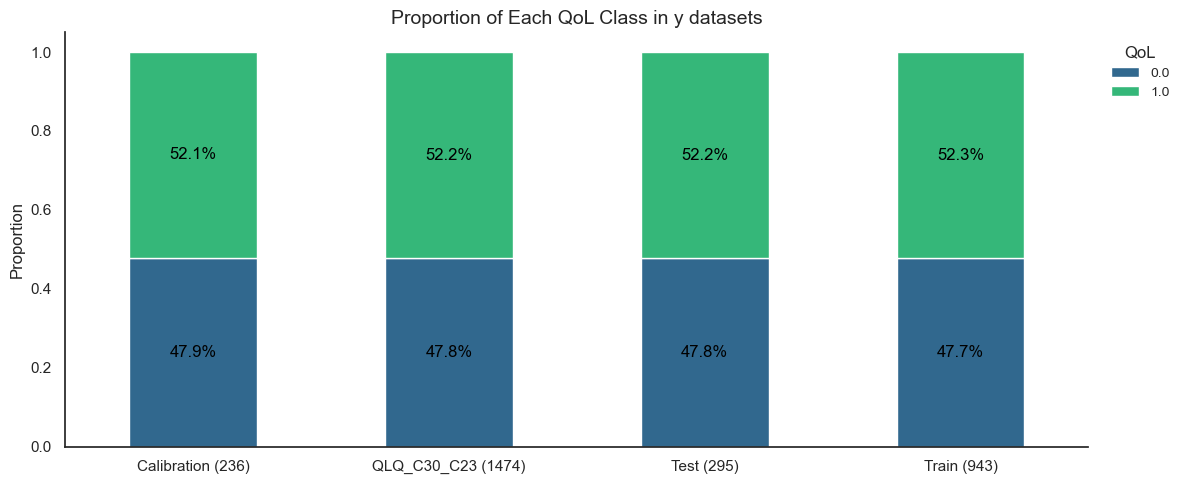

In [52]:
# Visualizamos las proporciones de las clases de QoL en todos los conjuntos
afn.viz_split_distributions([df['QoL'], y_train, y_test, y_cal], ['QLQ_C30_C23', 'Train', 'Test', 'Calibration'], 'QoL')

Podemos ver que la distribución de la variable objetivo tiene una variación inferior al 1% para cada clase en todos los conjuntos generados. Además, las 1474 observaciones del conjunto original se han separado en: 943 para entrenamiento, 295 para el test y 236 para la calibración. Todos los conjuntos presentan un balanceo de clases muy cercano a una proporción de 50-50.

In [53]:
# Guardamos los conjuntos en una lista para ser usada en las funciones auxiliares
datasets = [X_train, y_train]
labels = ['Aceptable', 'Mejorable']

## 2. Entrenamiento y Clasificación

La estrategia y metodología a seguir son las mismas que en la primera iteración del modelado, documentada en el cuaderno Modelado - Clasificación supervisada multiclase.

***- Entrenamiento***

Se entrena cada modelo con el conjunto de entrenamiento utilizando la técnica de validación cruzada k-fold con k = 5, integrada en el proceso de optimización de hiperparámetros mediante GridSearchCV, tal como se llevó a cabo en la clasificación multiclase.

***- Métrica*** 

A diferencia del enfoque multiclase, esta iteración binaria incorpora una etapa adicional de optimización del umbral de decisión. En lugar de mantener el umbral por defecto (0.5), se analiza el comportamiento del modelo en función de diferentes métricas —principalmente recall y f1-score macro— para determinar un punto de equilibrio con relevancia clínica.

Durante la búsqueda de hiperparámetros, el ajuste por F1 score maximiza la sensibilidad hacia la clase de interés (QoL mejorable), reduciendo los falsos negativos de forma significativa, ya que el conjunto de datos se encuentra muy balanceado. En la búsqueda del umbral de decisión óptimo, se observó que el uso de f1-score binario consigue un mejor compromiso entre la correcta detección de casos y la contención de falsos positivos. 

***- Clasificación***

Una vez identificado el mejor modelo (estimator) mediante la combinación óptima de hiperparámetros y umbral de decisión, se realiza la predicción sobre el conjunto de prueba. Los resultados se comparan con los del conjunto de entrenamiento para detectar posibles síntomas de sobreajuste y evaluar la calidad final de la clasificación.

Para la clasificación se entrenarán los siguientes modelos:

- Decision Tree 
- Random Forest
- XGBoost
- CatBoost
- LightGBM

### 2.1 Decision Tree

Para mayor información sobre este y los modelos siguientes se puede consultar el cuaderno de clasificación multiclase.

In [54]:
# Instanciamos el modelo 
decision_tree =  DecisionTreeClassifier(random_state=73)
# Establecemos un diccionario con los valores de los parámetros que tomará el modelo en el entrenamiento
dt_parameters = {
    # Criterios para medir la ganancia de información (calidad de la división)
    'criterion': ['entropy'],
    # Estrategias de división
    'splitter': ['random'],
    # Máxima profundidades del árbol (None permite la profundidad máxima posible)
    'max_depth': [11],
    # Mínimo de casos para dividir un nodo
    'min_samples_split': [3],
    # Mínimo de casos en las hojas
    'min_samples_leaf': [8],
    # Factor de poda
    'ccp_alpha': [0.003],
}
# Creamos la grilla de búsqueda de parámetros
dt_grid = GridSearchCV(
    estimator=decision_tree, 
    param_grid=dt_parameters, 
    verbose=1,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)
# Entrenamos los modelos generados por la grilla
%time dt_grid.fit(X_train, y_train)
# Visualización de los resultados
print('Media de F1 score: %.3f' % dt_grid.best_score_)
print('Desviación estándar: ', dt_grid.cv_results_['std_test_score'][dt_grid.best_index_].round(3))
print('Parámetros que producen el mejor clasificador: ')
print('Criterio: ', dt_grid.best_params_['criterion'])
print('Estrategia: ', dt_grid.best_params_['splitter'])
print('Profundidad máxima: ', dt_grid.best_params_['max_depth'])
print('Mínimo de muestras por división: ', dt_grid.best_params_['min_samples_split'])
print('Mínimo de muestras por hoja: ', dt_grid.best_params_['min_samples_leaf'])
print('Factor de poda: ', dt_grid.best_params_['ccp_alpha'])
print('Cantidad de nodos: ', dt_grid.best_estimator_.tree_.node_count)
print('Cantidad de hojas: ', dt_grid.best_estimator_.tree_.n_leaves)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
CPU times: user 31.8 ms, sys: 70.6 ms, total: 102 ms
Wall time: 4.66 s
Media de F1 score: 0.764
Desviación estándar:  0.018
Parámetros que producen el mejor clasificador: 
Criterio:  entropy
Estrategia:  random
Profundidad máxima:  11
Mínimo de muestras por división:  3
Mínimo de muestras por hoja:  8
Factor de poda:  0.003
Cantidad de nodos:  75
Cantidad de hojas:  38


Este modelo alcanzó una media de F1-score de 0.764, con una desviación estándar de 0.018 en las cinco particiones de la validación cruzada. Estos valores indican un buen rendimiento general y una estabilidad razonable entre pliegues.

El uso del criterio entropy implica que el modelo prioriza divisiones que maximizan la ganancia de información, mientras que la estrategia de división random introduce cierta aleatoriedad en la selección de características candidatas, lo que puede ayudar a evitar sobreajuste en árboles profundos. La poda suave aplicada con un factor de 0.003 también contribuye a controlar la complejidad del modelo y a mejorar su capacidad de generalización.

Generamos las predicciones del conjunto de prueba. Luego, nos valemos de la función auxiliar viz_classification_reports que se encargará de mostrar el reporte de las métricas y graficar la comparativa de entre ambos conjuntos.

Reporte sobre el conjunto de ENTRENAMIENTO:
              precision    recall  f1-score   support

         0.0       0.80      0.79      0.80       450
         1.0       0.81      0.82      0.82       493

    accuracy                           0.81       943
   macro avg       0.81      0.81      0.81       943
weighted avg       0.81      0.81      0.81       943

Reporte sobre el conjunto de validation:  VALIDATION
              precision    recall  f1-score   support

         0.0       0.69      0.71      0.70       141
         1.0       0.73      0.71      0.72       154

    accuracy                           0.71       295
   macro avg       0.71      0.71      0.71       295
weighted avg       0.71      0.71      0.71       295



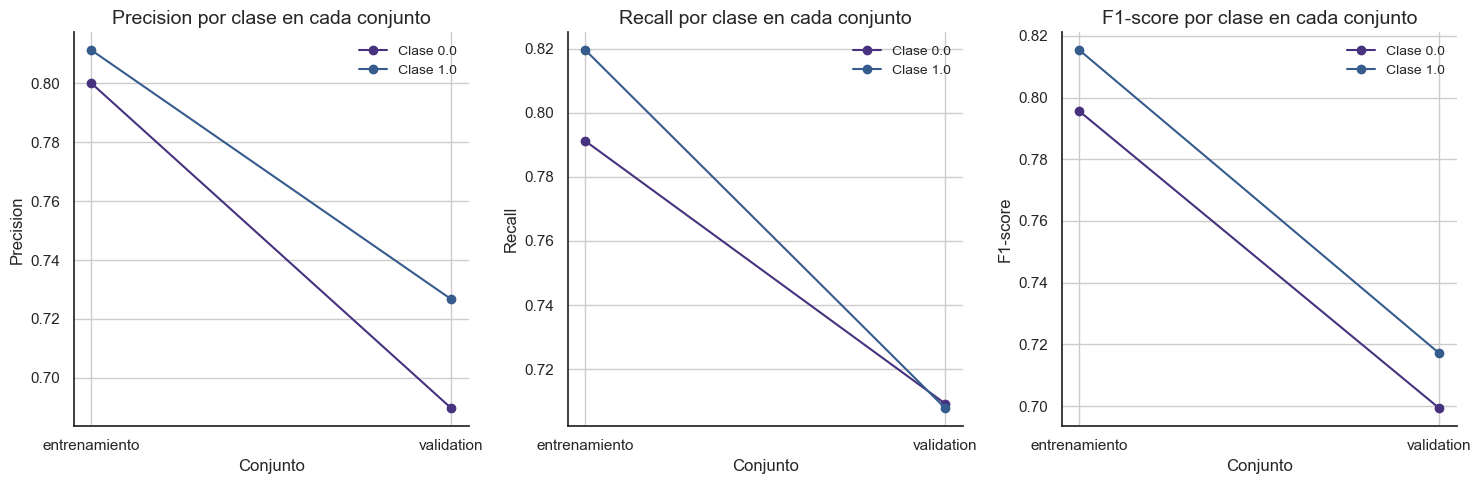

In [55]:
# Obtenemos el modelo con los mejores hiperparámetros
dt_model = dt_grid.best_estimator_
# Obtenemos las puntuaciones crudas para cada clase para las predicciones en el conjunto de prueba y mostramos los resultados
y_pred_dt = dt_model.predict_proba(X_test)
y_pred_train_dt, y_pred_test_dt, dt_report = afn.viz_classification_reports(dt_model, X_train, y_train, X_test, y_test)

El modelo entrenado con los hiperparámetros óptimos mostró un buen rendimiento en el conjunto de entrenamiento, con un accuracy del 81%, un f1-score macro de 0.81 y una buena capacidad para identificar correctamente la clase de interés (QoL mejorable), alcanzando un recall del 0.82 para la clase positiva.

En el conjunto de prueba, como es esperable, las métricas disminuyen ligeramente. El accuracy desciende al 71%, y el f1-score para la clase mejorable desciende a 0.71. La clase aceptable muestra una caída del recall del 79% en entrenamiento al 71% en prueba.

Los gráficos comparativos permiten observar con claridad esta diferencia: el rendimiento del modelo es consistente en ambas clases, con menos variación entre conjuntos para la clase aceptable, mientras que en la clase mejorable se detecta una pérdida más acusada en recall.

Este patrón es clínicamente aceptable dentro del objetivo del sistema, que prioriza identificar correctamente a los pacientes con calidad de vida mejorable, aunque implique una menor precisión en la clase complementaria. En conjunto, el modelo mantiene un equilibrio razonable entre sensibilidad y precisión, con un desempeño relativamente robusto sin signos evidentes de sobreajuste.

A continuación, se incorpora el estudio del umbral de decisión para optimizar la clasificación. Para ello, se utiliza una función auxiliar que grafica la evolución de distintas métricas —precision, recall, accuracy y f1-score— conforme se incrementa el umbral. El umbral óptimo se define como aquel que maximiza una métrica concreta (en nuestro caso, f1-score), permitiendo encontrar un equilibrio entre sensibilidad y precisión que se ajuste al objetivo clínico del modelo. El gráfico se complementa con el valor de la curva ROC, que ofrece una visión global del poder discriminatorio del modelo independientemente del umbral seleccionado.

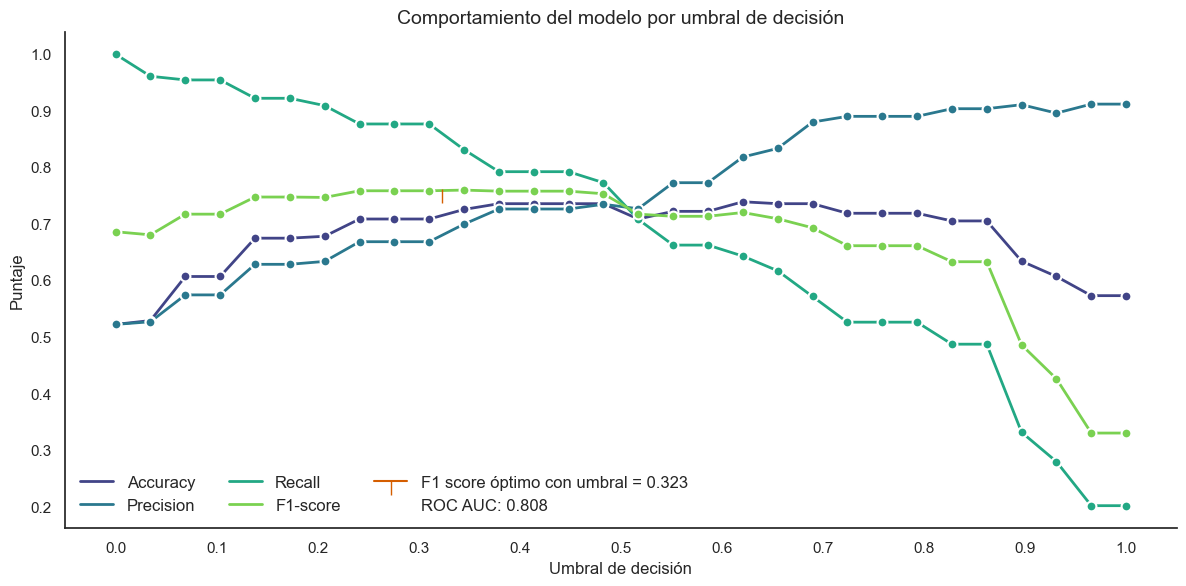

In [56]:
# Calculamos los umbrales y los visualizamos
dt_best_threshold, dt_metrics = afn.viz_threshold_behavior(dt_model, X_test, y_test, num_thresholds=30, metric=f1_score)
# Extraemos las puntuaciones crudas de la clase mejorable de las predicciones del modelo
probs_dt = y_pred_dt[:, 1]
# Seleccionamos aquellas que satisfacen el umbral óptimo encontrado
y_pred_proba_dt = (probs_dt >= dt_best_threshold)
# Guardamos las métricas para realizar la comparación con los otros modelos
dt_metrics['model'] = 'Decision Tree'

In [57]:
# Analizamos el reporte con el umbral ajustado
print("Reporte con umbral ajustado:")
print(classification_report(y_test, y_pred_proba_dt, target_names=labels))

Reporte con umbral ajustado:
              precision    recall  f1-score   support

   Aceptable       0.78      0.57      0.66       141
   Mejorable       0.68      0.86      0.76       154

    accuracy                           0.72       295
   macro avg       0.73      0.71      0.71       295
weighted avg       0.73      0.72      0.71       295



El umbral óptimo se identificó en 0.323, con el cual se alcanza un f1 score de 0.76 con una sensibilidad del 86% para la clase mejorable y una precisión del 68%, lo que indica una buena capacidad para detectar correctamente los casos relevantes aunque genera un exceso de falsos positivos. Al mismo tiempo, la clase QoL aceptable logra una precisión del 78%, aunque su recall disminuye a 57%, un efecto esperado al desplazar el umbral hacia la clase positiva.

Observamos la matriz de confusión para visualizar mejor el cambio que produce el ajuste del umbral.

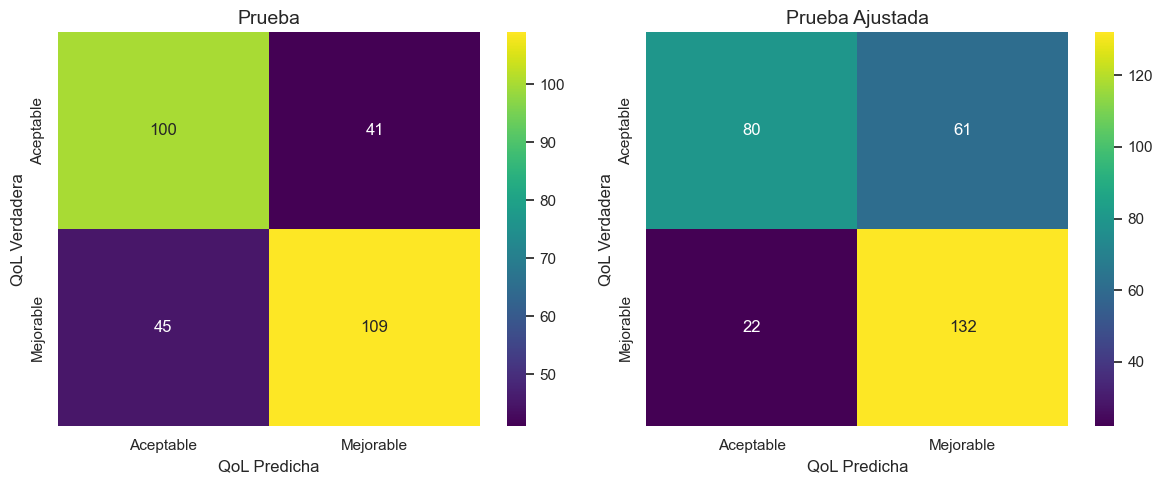

In [58]:
afn.viz_confusion_matrix_thres(labels, y_test, y_pred_test_dt, y_pred_proba_dt)

La matriz de confusión confirma la mejora sustancial en la capacidad del modelo para identificar correctamente los casos de calidad de vida mejorable tras ajustar el umbral de decisión. El número de verdaderos positivos aumenta considerablemente, pasando de 109 a 132, mientras que los falsos negativos se reducen más de la mitad, de 45 a 22. Esto implica una mayor sensibilidad hacia la clase clínicamente relevante, lo cual es fundamental para el objetivo del sistema.

Este ajuste se logra con un coste moderado: se observa un incremento en los falsos positivos (de 41 a 61) y una reducción del 20% en la correcta clasificación de la clase aceptable (de 100 a 80), aunque esta pérdida no es significativa si se compara con la mejora global obtenida en la clase de interés. En conjunto, el modelo ajustado ofrece un rendimiento más equilibrado y alineado con el propósito clínico del sistema, priorizando la identificación de los casos con potencial de intervención sin comprometer excesivamente la precisión.

## 2.3 Random Forest



In [59]:
# Instanciamos el modelo
rf_model = RandomForestClassifier(
    random_state = 73,
    n_jobs=-1
)
# Definimos el diccionario de parámetros
rf_parameters = {
    'criterion': ['gini'],
    # Número de árboles en cada modelo
    'n_estimators': [150],
    'max_depth': [12],
    'min_samples_split': [3],
    'min_samples_leaf': [3],
    'ccp_alpha': [0.001]
}
# Instanciamos la grilla de búsqueda
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_parameters,
    scoring='f1_macro',
    verbose=True,
    cv=5,
    n_jobs=-1
)
# Realizamos el entrenamiento
%time rf_grid.fit(X_train, y_train)
# Finalmente, visualizamos los resultados
print('Media de F1 score: %.3f' % rf_grid.best_score_)
print('Desviación estándar: ', rf_grid.cv_results_['std_test_score'][rf_grid.best_index_].round(3))
print('Parámetros que producen el clasificador óptimo: ')
print('Criterio: ', rf_grid.best_params_['criterion'])
print('Profundidad máxima: ', rf_grid.best_params_['max_depth'])
print('Mínimo de muestras por división: ', rf_grid.best_params_['min_samples_split'])
print('Mínimo de muestras por hoja: ', rf_grid.best_params_['min_samples_leaf'])
print('Factor de poda: ', rf_grid.best_params_['ccp_alpha'])
print('Cantidad de árboles: ', rf_grid.best_params_['n_estimators'])
print('Cantidad de nodos del primer árbol: ', rf_grid.best_estimator_.estimators_[0].tree_.node_count)
print('Cantidad de hojas del primer árbol: ', rf_grid.best_estimator_.estimators_[0].tree_.n_leaves)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
CPU times: user 236 ms, sys: 83.7 ms, total: 320 ms
Wall time: 2.62 s
Media de F1 score: 0.791
Desviación estándar:  0.015
Parámetros que producen el clasificador óptimo: 
Criterio:  gini
Profundidad máxima:  12
Mínimo de muestras por división:  3
Mínimo de muestras por hoja:  3
Factor de poda:  0.001
Cantidad de árboles:  150
Cantidad de nodos del primer árbol:  137
Cantidad de hojas del primer árbol:  69


El modelo encontrado alcanza un F1 score de 0.792, lijeramente superior al modelo anterior, con una desviación estándar de 0.018 que indica una estabilidad en todas las hojas de la validación cruzada. Tiene una complejidad relativamente simple con 100 árboles y una profundidad máxima de 11 niveles. Se le ha aplicado un factor alpha muy suave de 0.006 que reduce la complejidad y mejora el sobreajuste. Si observamos el primer árbol del bosque, encontramos que está formado por 43 nodos y 22 hojas.

Continuamos con el entrenamiento y la obtención de las puntuaciones crudas asignadas por el mejor *estimator*

Reporte sobre el conjunto de ENTRENAMIENTO:
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89       450
         1.0       0.92      0.87      0.90       493

    accuracy                           0.90       943
   macro avg       0.90      0.90      0.89       943
weighted avg       0.90      0.90      0.90       943

Reporte sobre el conjunto de validation:  VALIDATION
              precision    recall  f1-score   support

         0.0       0.77      0.85      0.81       141
         1.0       0.85      0.77      0.81       154

    accuracy                           0.81       295
   macro avg       0.81      0.81      0.81       295
weighted avg       0.81      0.81      0.81       295



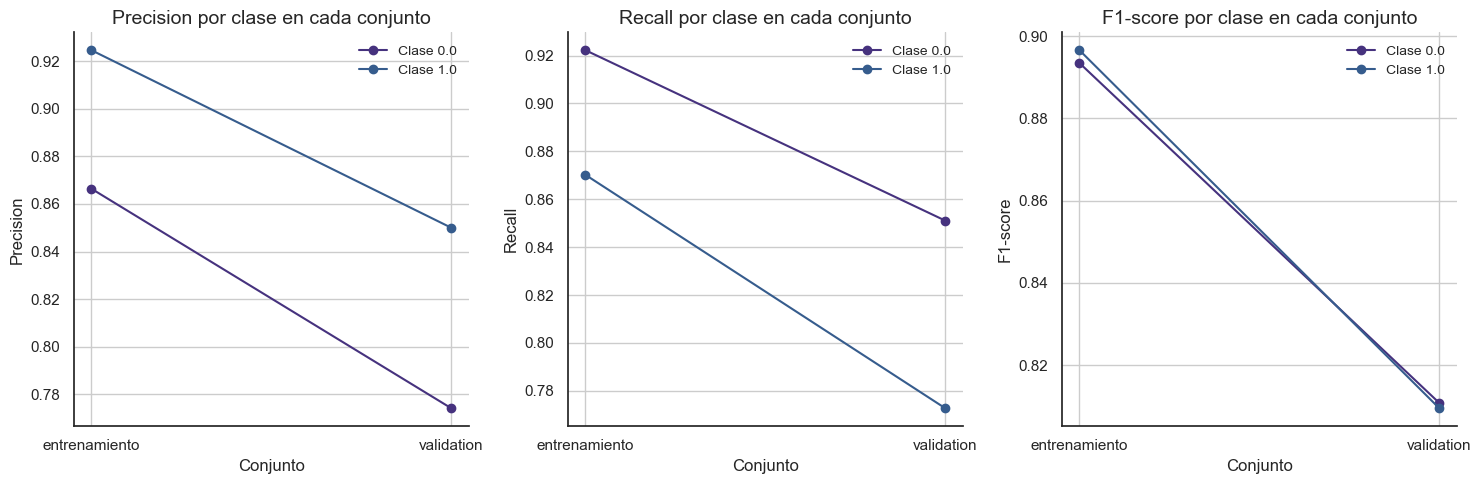

In [60]:
# Continuamos con los mismos pasos que en el modelo anterior
rf_model = rf_grid.best_estimator_
y_pred_rf = rf_model.predict_proba(X_test)
y_pred_train_rf, y_pred_test_rf, rf_report = afn.viz_classification_reports(rf_model, X_train, y_train, X_test, y_test)

El modelo de ensamble representa una mejoría sustancial con respecto al árbol único. Por un lado, la precisión ha aumentado considerablemente, para ambas clases, junto con la exactitud global. Al observar el recall encontramos que la mejoría se ha producido en ambas clases de forma uniforme, es decir, el modelo ha podido diferenciar mucho mejor las clases y ha recortado tanto los falsos positivos como los falsos negativos. Los gráficos nos muestran como las caídas en las métricas no muestran una gran diferencia entre ambos conjuntos confirmando que no existe un sobreajuste preocupante.

Continuamos con la búsqueda del umbral óptimo como anteriormente.

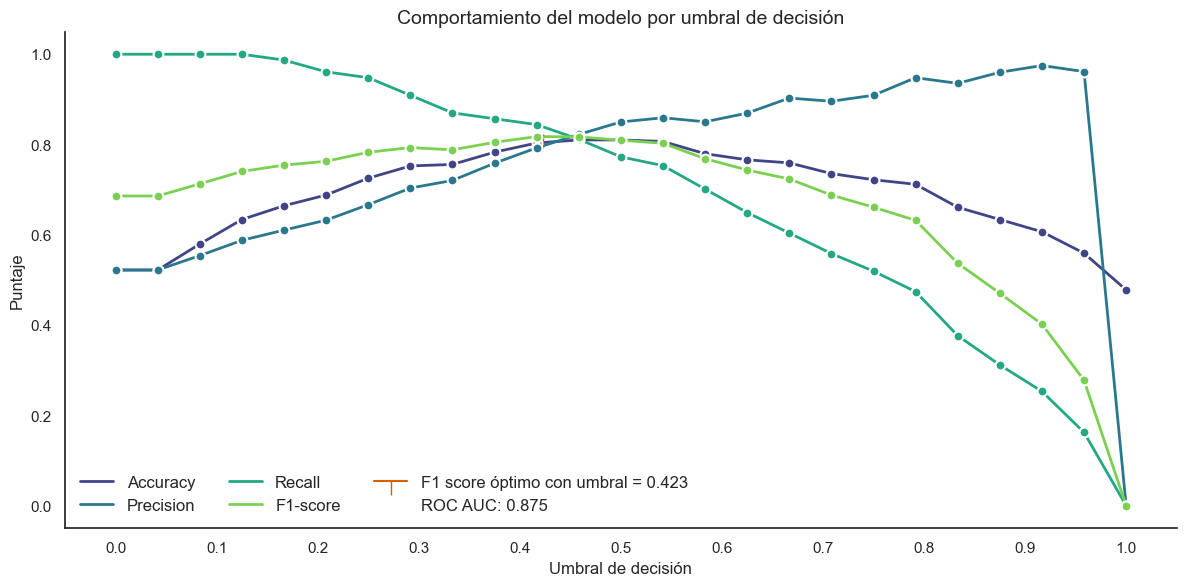

In [61]:
# Aplicamos el mismo flujo que en el caso anterior
rf_best_threshold, rf_metrics = afn.viz_threshold_behavior(rf_model, X_test, y_test, num_thresholds=25)
probs_rf = y_pred_rf[:, 1]
y_pred_proba_rf = (probs_rf >= rf_best_threshold)
rf_metrics['model'] = 'Random Forest'

In [62]:
print("Reporte con umbral ajustado:")
print(classification_report(y_test, y_pred_proba_rf, target_names=labels))

Reporte con umbral ajustado:
              precision    recall  f1-score   support

   Aceptable       0.82      0.77      0.80       141
   Mejorable       0.80      0.84      0.82       154

    accuracy                           0.81       295
   macro avg       0.81      0.81      0.81       295
weighted avg       0.81      0.81      0.81       295



En este caso, podemos ver que el umbral ajustado no mejora tan significativamente la clasificación como en el caso anterior. Tenemos una muy leve mejoría en el f1 score de la clase 1 junto con una disminución del recall que nos indica un leve aumento de los falsos positivos. En todo caso, los cambios son mínimos indicando un posible límite en la diferenciación de las características de las clases. 

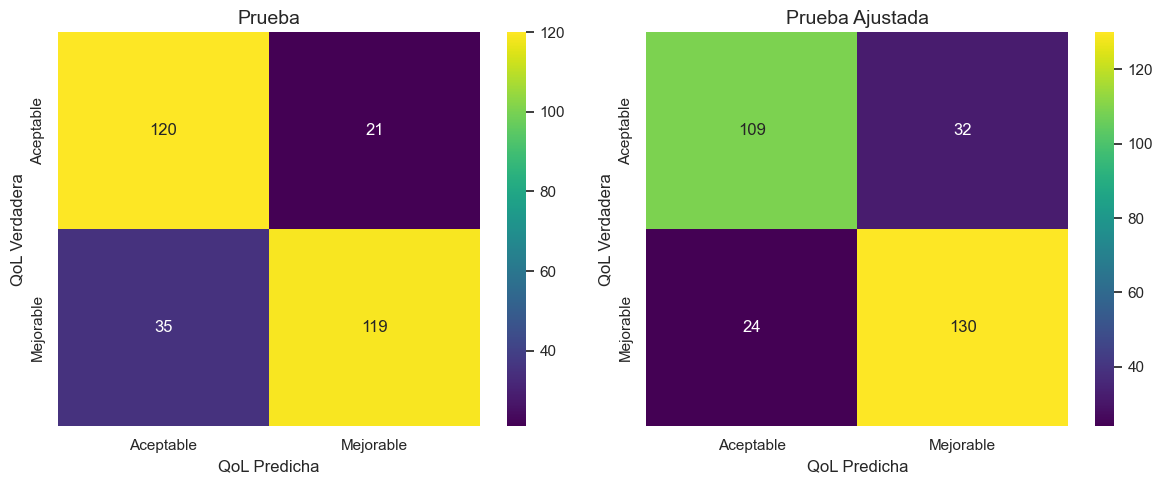

In [63]:
# Graficamos la matriz de confusión antes y después del ajuste
afn.viz_confusion_matrix_thres(labels, y_test, y_pred_test_rf, y_pred_proba_rf)

Como hemos mencionado anteriormente, el ajuste del umbral reduce los falsos negativos mejorando la clasificación de la clase 1, a costa de un aumento de los falsos positivos. Estos casos «limítrofes» son muy difíciles de diferenciar. Esta idea puede visualizarse claramente en el siguiente gráfico de dispersión que representa los casos clasificados correctamente e incorrectamente respecto al umbral de decisión. Como se muestra, existe una zona intermedia donde se concentran los falsos positivos, lo que pone en evidencia la dificultad de clasificar los casos limítrofes incluso tras el ajuste óptimo del umbral.

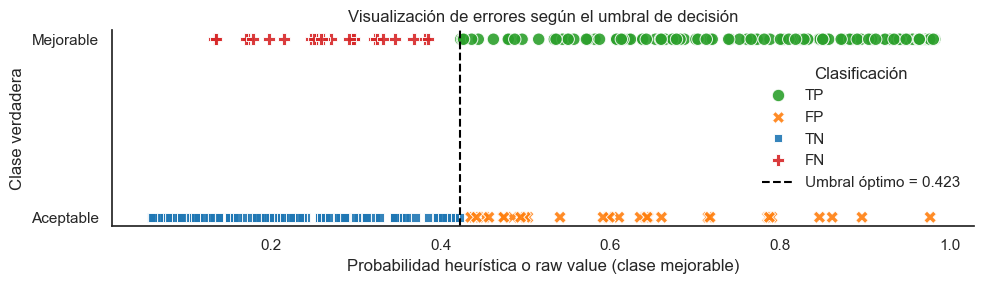

In [64]:
afn.viz_threshold_optimization(probs_rf, y_test, y_pred_proba_rf, rf_best_threshold)

El gráfico evidencia como el umbral fija la clasificación en el punto donde conseguir un nuevo verdadero positivo alcanzando la cruz roja (falso negativo), significa aumentar los falsos positivos: convertir los cuadrados azules (verdaderos negativos) en cruces naranjas. Las dispersiones de las puntuaciones crudas en ambas clases hacen que no sea posible una diferenciación más eficaz con este modelo.

### 2.3 XGBoost

In [65]:
# Realizamos el mismo flujo de trabajo que en los modelos anteriores
xg_parameters = {
    'eta': [0.05],
    'max_depth': [10],
    'min_child_weight': [4],
    'n_estimators': [100],
    'subsample': [0.5]
}
xg_model = XGBClassifier(
    objective='binary:logistic',               
    eval_metric='logloss',     
    random_state=73,
)
xg_grid = GridSearchCV(
    estimator=xg_model,
    param_grid=xg_parameters,
    scoring='recall',
    cv=5,
    verbose=True,
    n_jobs=-1
)
%time xg_grid.fit(X_train, y_train)
print('Media de F1 score: %.3f' % xg_grid.best_score_)
print('Desviación estándar: ', xg_grid.cv_results_['std_test_score'][xg_grid.best_index_].round(3))
print('Parámetros que producen el clasificador óptimo: ')
print('Tasa de aprendizaje: ', xg_grid.best_params_['eta'])
print('Profundidad máxima: ', xg_grid.best_params_['max_depth'])
print('Mínimo peso de división: ', xg_grid.best_params_['min_child_weight'])
print('Número de árboles: ', xg_grid.best_params_['n_estimators'])
print('Subsample: ', xg_grid.best_params_['subsample'])

Fitting 5 folds for each of 1 candidates, totalling 5 fits
CPU times: user 192 ms, sys: 693 ms, total: 885 ms
Wall time: 4.96 s
Media de F1 score: 0.771
Desviación estándar:  0.038
Parámetros que producen el clasificador óptimo: 
Tasa de aprendizaje:  0.05
Profundidad máxima:  10
Mínimo peso de división:  4
Número de árboles:  100
Subsample:  0.5


El modelo encontrado obtiene una muy leve mejoría en el valor de F1 macro con respecto a los anteriores. La cantidad de estimadores es menor que en el caso del random forest y presenta una profundidad 4 niveles menor. En cuanto al subsample, podemos ver que la división se produce con el 50% de las variables, lo que reduce el riesgo de sobreajuste.

Reporte sobre el conjunto de ENTRENAMIENTO:
              precision    recall  f1-score   support

         0.0       0.83      0.87      0.85       450
         1.0       0.87      0.84      0.85       493

    accuracy                           0.85       943
   macro avg       0.85      0.85      0.85       943
weighted avg       0.85      0.85      0.85       943

Reporte sobre el conjunto de validation:  VALIDATION
              precision    recall  f1-score   support

         0.0       0.76      0.80      0.78       141
         1.0       0.81      0.77      0.79       154

    accuracy                           0.78       295
   macro avg       0.78      0.78      0.78       295
weighted avg       0.78      0.78      0.78       295



[codecarbon INFO @ 16:45:18] Energy consumed for RAM : 0.000050 kWh. RAM Power : 6.0 W
[codecarbon INFO @ 16:45:18] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 16:45:18] Energy consumed for All CPU : 0.000355 kWh
[codecarbon INFO @ 16:45:18] 0.000405 kWh of electricity used since the beginning.


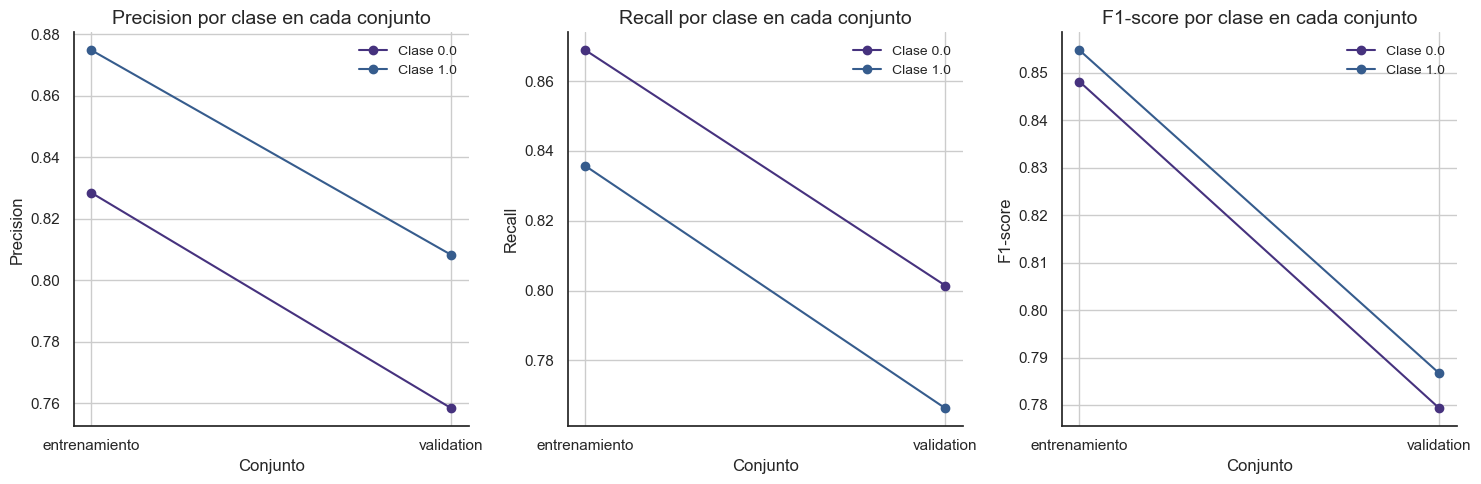

In [66]:
# Continuamos con el análisis del mejor modelo encontrado
xg_model = xg_grid.best_estimator_
y_pred_xg = xg_model.predict_proba(X_test)
y_pred_train_xg, y_pred_val_xg, xg_report= afn.viz_classification_reports(xg_model, X_train, y_train, X_test, y_test)

Los resultados muestran un comportamiento muy similar en ambos conjuntos indicando una buena generalización con datos nuevos. Vamos a estudiar si la optimización del umbral aporta mejoras en la clasificación.

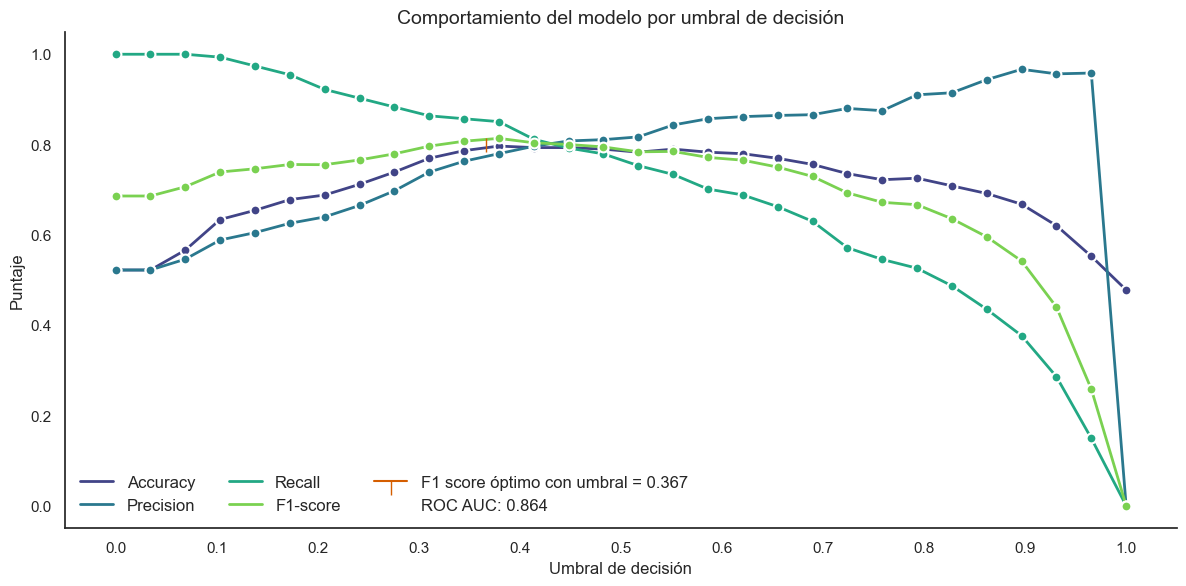

In [67]:
# Obtenemos el umbral y graficamos su evolución
xg_best_threshold, xg_metrics = afn.viz_threshold_behavior(xg_model, X_test, y_test, num_thresholds=30)
probs_xg = y_pred_xg[:, 1]
y_pred_proba_xg = (probs_xg >= xg_best_threshold)
xg_metrics['model'] = 'XGBoost'

In [68]:
print(classification_report(y_test, y_pred_proba_xg))

              precision    recall  f1-score   support

         0.0       0.82      0.73      0.77       141
         1.0       0.78      0.86      0.81       154

    accuracy                           0.80       295
   macro avg       0.80      0.79      0.79       295
weighted avg       0.80      0.80      0.80       295



La optimización del umbral tiene poco margen de maniobra y las mejoras aportadas son apenas perceptibles, ya que todas las métricas presentan variaciones mínimas. Podemos conjeturar que no hay mayores cambios que unas pocas observaciones. De hecho, la curva de roc es prácticamente la misma, con muy poco aumento con respecto a Random Forest.

Vamos a visualizarlo mediante la matriz de confusión.

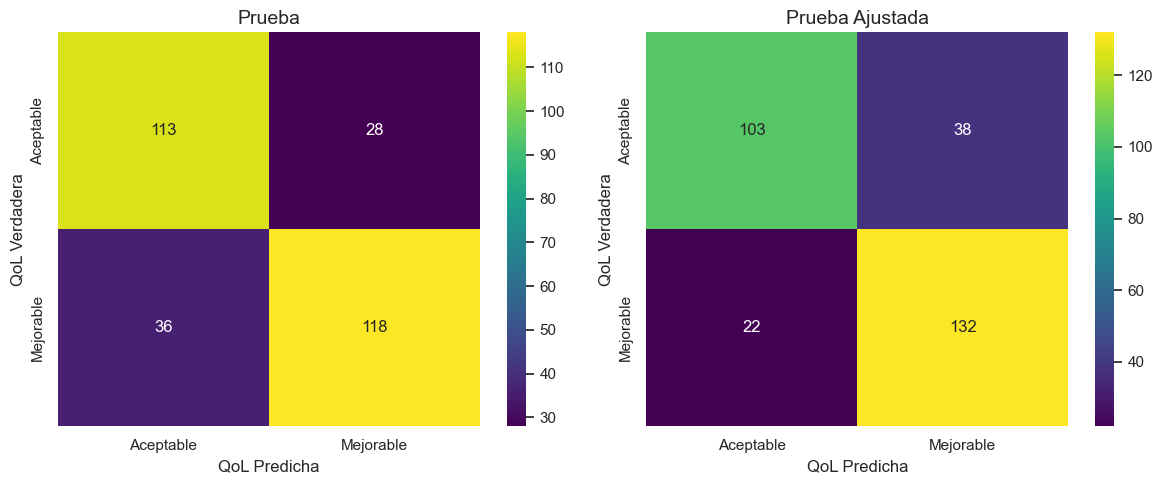

In [69]:
afn.viz_confusion_matrix_thres(labels, y_test, y_pred_val_xg, y_pred_proba_xg)

Efectivamente, comprobamos que el único cambio es una leve mejoría en la clasificación de la clase mejorable.

Vamos a observar este límite en la mejora con la visualización del umbral y las puntuaciones crudas.

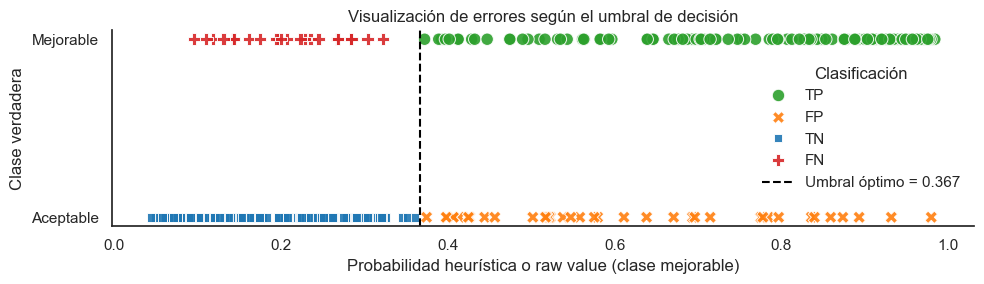

In [70]:
afn.viz_threshold_optimization(probs_xg, y_test, y_pred_proba_xg, xg_best_threshold)

### 2.4 CatBoost

In [71]:
# Repetimos el flujo de trabajo para el modelo
cb_parameters = {
    'depth': [7],
    'iterations': [100],
    'learning_rate': [0.06],
    'l2_leaf_reg': [6],
    'bagging_temperature': [0],
    'rsm': [0.9],
    'leaf_estimation_iterations': [3]
}
cb_model = CatBoostClassifier(
    loss_function='Logloss', 
    eval_metric='Logloss', 
    random_state=73,
    early_stopping_rounds=50,
    verbose=False
)
cb_grid = GridSearchCV(
    estimator=cb_model,
    param_grid=cb_parameters,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)
%time cb_grid.fit(X_train, y_train)

print('Media de F1 score: %.3f' % cb_grid.best_score_)
print('Desviación estándar: ', cb_grid.cv_results_['std_test_score'][cb_grid.best_index_].round(3))
print('Parámetros que producen el clasificador óptimo: ')
print('Profundidad: ', cb_grid.best_params_['depth'])
print('Tasa de aprendizaje: ', cb_grid.best_params_['learning_rate'])
print('Regularización en hojas: ', cb_grid.best_params_['l2_leaf_reg'])
print('Muestreo aleatorio: ', cb_grid.best_params_['bagging_temperature'])
print('Porcentaje de variables utilizado: ', cb_grid.best_params_['rsm'])
print('Número de árboles: ', cb_grid.best_params_['iterations'])
print('Iteraciones estimadas de las hojas: ', cb_grid.best_params_['leaf_estimation_iterations'])

CPU times: user 78.1 ms, sys: 23.1 ms, total: 101 ms
Wall time: 4.18 s
Media de F1 score: 0.787
Desviación estándar:  0.016
Parámetros que producen el clasificador óptimo: 
Profundidad:  7
Tasa de aprendizaje:  0.06
Regularización en hojas:  6
Muestreo aleatorio:  0
Porcentaje de variables utilizado:  0.9
Número de árboles:  100
Iteraciones estimadas de las hojas:  3


Para el algoritmo CatBoost el modelo encontrado en el espacio de hiperparámetros presenta mayor cantidad de árboles que en los casos anteriores, aunque con menor profundidad. La tasa de aprendizaje relativamente baja (0.06) indica que el modelo realiza actualizaciones suaves en cada iteración. La regularización aplicada en las hojas y la ausencia de muestreo aleatorio reflejan una preferencia por utilizar todos los datos en cada iteración, lo que, junto con el uso del 100% de las variables en cada split, maximiza la información considerada para cada división.

El resultado de F1-score medio de 0.815 con una desviación estándar moderada (0.025) indica un buen rendimiento general y estabilidad en las predicciones del modelo a lo largo de las distintas particiones de validación cruzada, en la misma línea que XGBoost.

Reporte sobre el conjunto de ENTRENAMIENTO:
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86       450
         1.0       0.90      0.82      0.86       493

    accuracy                           0.86       943
   macro avg       0.86      0.86      0.86       943
weighted avg       0.86      0.86      0.86       943

Reporte sobre el conjunto de validation:  VALIDATION
              precision    recall  f1-score   support

         0.0       0.77      0.81      0.79       141
         1.0       0.82      0.77      0.79       154

    accuracy                           0.79       295
   macro avg       0.79      0.79      0.79       295
weighted avg       0.79      0.79      0.79       295



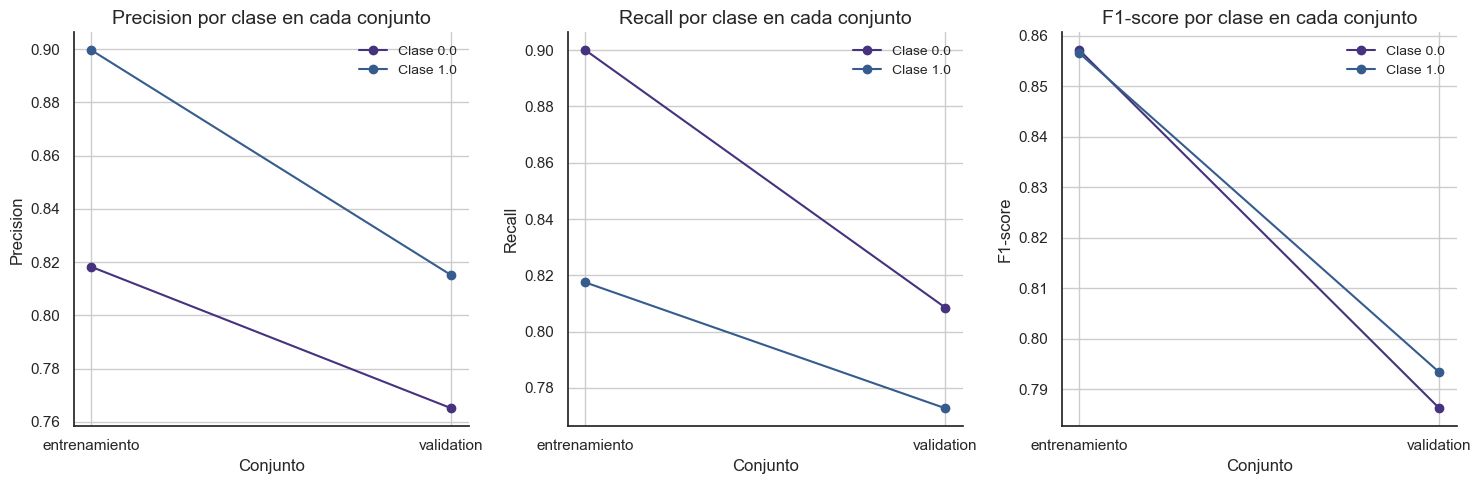

In [72]:
# Obtenemos los resultados del mejor modelo y graficamos los resultados
cb_model = cb_grid.best_estimator_
y_pred_cb = cb_model.predict_proba(X_test)
y_pred_train_cb, y_pred_val_cb, cb_report = afn.viz_classification_reports(cb_model, X_train, y_train, X_test, y_test)

Encontramos que el modelo CatBoost obtiene exactamente las mismas métricas que XGBoost para el conjunto de validación, a pesar de que presenta alguna leve mejora en el entrenamiento. Efectivamente, el F1 score continúa siendo 0.81 y 0.82 para la clase 0 y 1 respectivamente.

A continuación, analizamos si el ajuste del umbral aporta alguna mejora a la clasificación.

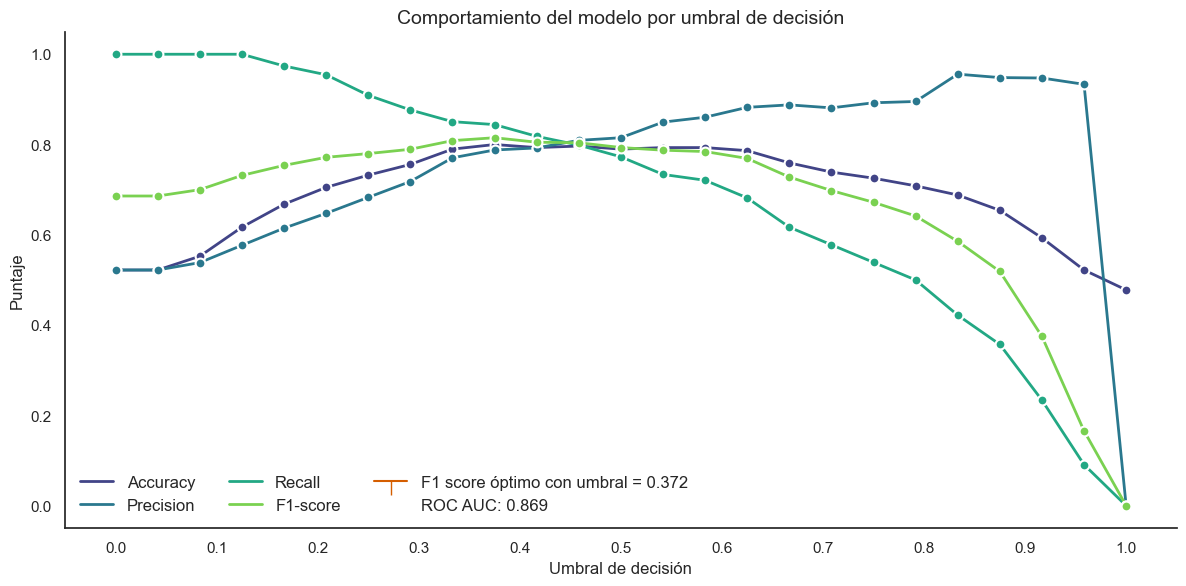

In [73]:
# Calculamos el umbral de decisión óptimo
cb_best_threshold, cb_metrics = afn.viz_threshold_behavior(cb_model, X_test, y_test, num_thresholds=25)
probs_cb = y_pred_cb[:, 1]
y_pred_proba_cb = (probs_cb >= cb_best_threshold)
cb_metrics['model'] = 'CatBoost'

In [74]:
print(classification_report(y_test, y_pred_proba_cb))

              precision    recall  f1-score   support

         0.0       0.82      0.75      0.78       141
         1.0       0.79      0.84      0.82       154

    accuracy                           0.80       295
   macro avg       0.80      0.80      0.80       295
weighted avg       0.80      0.80      0.80       295



Confirmamos que el comportamiento es ligéramente mejor que XGBoost obteniendo las mismas métricas con variaciones prácticamente imperceptibles.

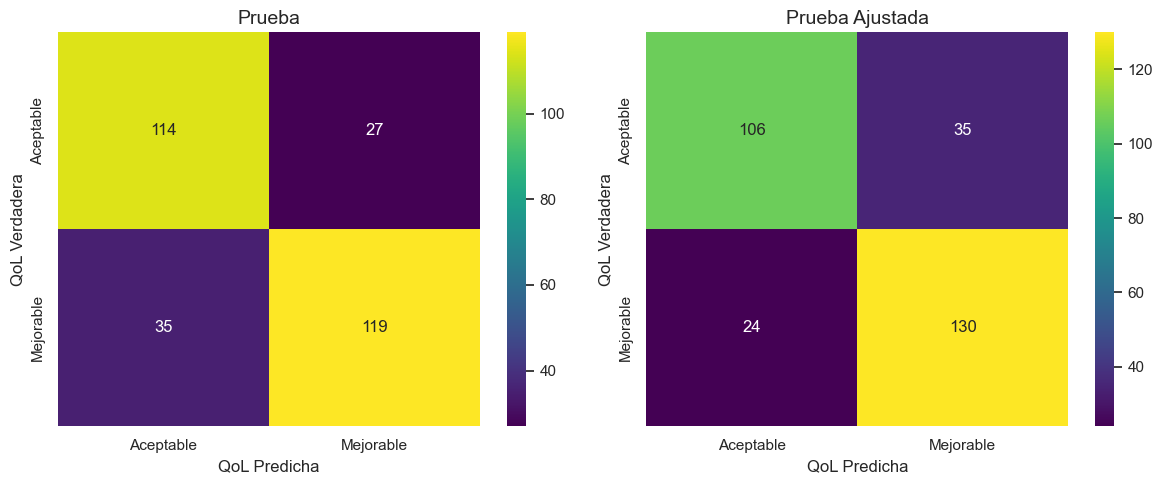

In [75]:
afn.viz_confusion_matrix_thres(labels, y_test, y_pred_val_cb, y_pred_proba_cb)

La matriz de confusión reafirma las conclusiones anteriores y vemos como el presente modelo genera un falso negativo menos aumentando la precisión de los verdaderos positivos para la clase 1. En definitiva, ambos modelos parecen alcanzar el mismo límite en la capacidad de diferenciación de ambas clases.

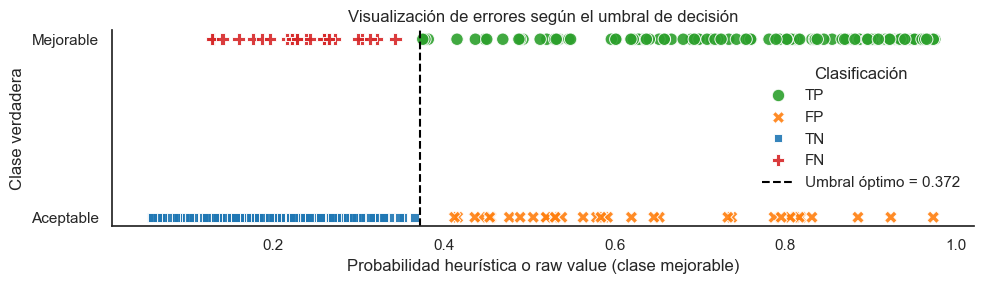

In [76]:
afn.viz_threshold_optimization(probs_cb, y_test, y_pred_proba_cb, cb_best_threshold)

En cuanto al umbral de decisión, encontramos que el costo de forzar una mejora muy leve en los verdaderos positivos tiene un coste mayor en la cantidad de falsos positivos que se generarían.

### 2.5 Light Gradient-Boosting Machine (LigthGBM)

In [77]:
lg_parameters = {
    'n_estimators': [100],          
    'learning_rate': [0.1],        
    'max_depth': [6],              
    'num_leaves': [3],             
    'min_child_samples': [3],      
    'reg_alpha': [0.1],            
    'reg_lambda': [0.05],                      
    'min_split_gain': [0.05]                   
}

lg_model = LGBMClassifier(
    objective='binary', 
    boosting_type='gbdt', 
    random_state=73, 
    verbose=0,
)

lg_grid = GridSearchCV(
    estimator=lg_model, 
    param_grid=lg_parameters, 
    scoring='f1_macro', 
    cv=5,
    n_jobs=-1,
)
X_train.columns = X_train.columns.str.replace(' ', '_')
X_test.columns = X_test.columns.str.replace(' ', '_')
X_test.columns = X_test.columns.str.replace(' ', '_')
%time lg_grid.fit(X_train, y_train)

print('Media de F1 score: %.3f' % lg_grid.best_score_)
print('Desviación estándar: ', lg_grid.cv_results_['std_test_score'][lg_grid.best_index_].round(3))
print('Parámetros que producen el clasificador óptimo: ')
print('Mínimo de árboles', lg_grid.best_params_['n_estimators'])
print('Profundidad: ', lg_grid.best_params_['max_depth'])
print('Tasa de aprendizaje: ', lg_grid.best_params_['learning_rate'])
print('Número de leaves: ', lg_grid.best_params_['num_leaves'])
print('Mínimo de muestras', lg_grid.best_params_['min_child_samples'])
print('Alpha', lg_grid.best_params_['reg_alpha'])
print('Lambda', lg_grid.best_params_['reg_lambda'])
print('Mínimo de ganancia', lg_grid.best_params_['min_split_gain'])

CPU times: user 51.7 ms, sys: 118 ms, total: 170 ms
Wall time: 3.68 s
Media de F1 score: 0.787
Desviación estándar:  0.015
Parámetros que producen el clasificador óptimo: 
Mínimo de árboles 100
Profundidad:  6
Tasa de aprendizaje:  0.1
Número de leaves:  3
Mínimo de muestras 3
Alpha 0.1
Lambda 0.05
Mínimo de ganancia 0.05


El modelo óptimo de LightGBM obtenido se compone de un mínimo de 100 árboles, con una profundidad máxima de 6 niveles y solo 3 hojas por árbol, lo que sugiere una estructura deliberadamente simple, orientada a limitar divisiones innecesarias.

La tasa de aprendizaje utilizada fue de 0.1, un valor moderado que permite converger rápidamente sin saltos excesivos. En cuanto a regularización, se aplicaron valores bajos, pero no nulos tanto en alpha (0.1) como en lambda (0.05), lo que introduce una penalización leve que ayuda a mejorar la capacidad de generalización del modelo. También se estableció un umbral mínimo de ganancia de 0.05 para realizar splits, lo que impone una exigencia adicional a la hora de dividir nodos.

A nivel de rendimiento, el modelo alcanzó una media de f1-score de 0.787, con una desviación estándar de 0.015. Una vez más, indica un desempeño estable en los distintos pliegues de validación cruzada, con una leve caída respecto a los modelos anteriores.

In [78]:
# Predecimos con el mejor estimador
lg_model = lg_grid.best_estimator_
y_pred_lg = lg_model.predict_proba(X_test)

Reporte sobre el conjunto de ENTRENAMIENTO:
              precision    recall  f1-score   support

         0.0       0.78      0.85      0.82       450
         1.0       0.85      0.79      0.82       493

    accuracy                           0.82       943
   macro avg       0.82      0.82      0.82       943
weighted avg       0.82      0.82      0.82       943

Reporte sobre el conjunto de validation:  VALIDATION
              precision    recall  f1-score   support

         0.0       0.76      0.83      0.80       141
         1.0       0.83      0.77      0.80       154

    accuracy                           0.80       295
   macro avg       0.80      0.80      0.80       295
weighted avg       0.80      0.80      0.80       295



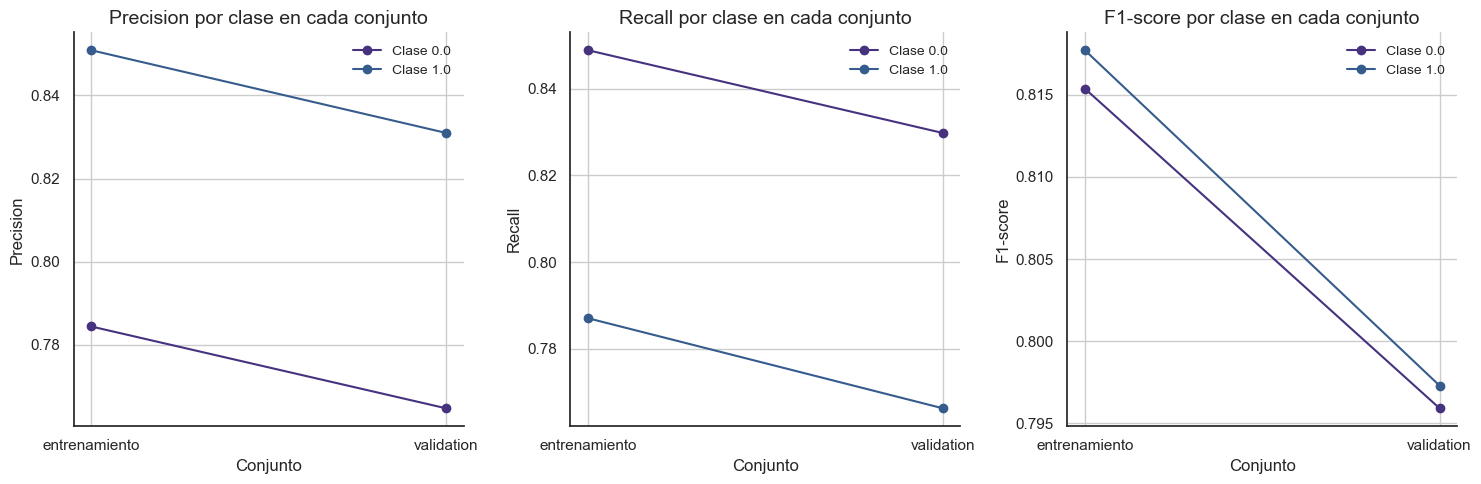

In [79]:
y_pred_train_lg, y_pred_val_lg, lg_report = afn.viz_classification_reports(lg_model, X_train, y_train, X_test, y_test)

El modelo se comporta de forma similar a Random Forest, obteniendo resultados similares en todas las métricas. El rendimiento se mantiene alto, con una media ponderada de f1-score de 0.80. Ambas clases muestran valores idénticos para f1 score. La caída moderada respecto al entrenamiento es esperada y refleja un comportamiento saludable del modelo frente a datos no vistos.

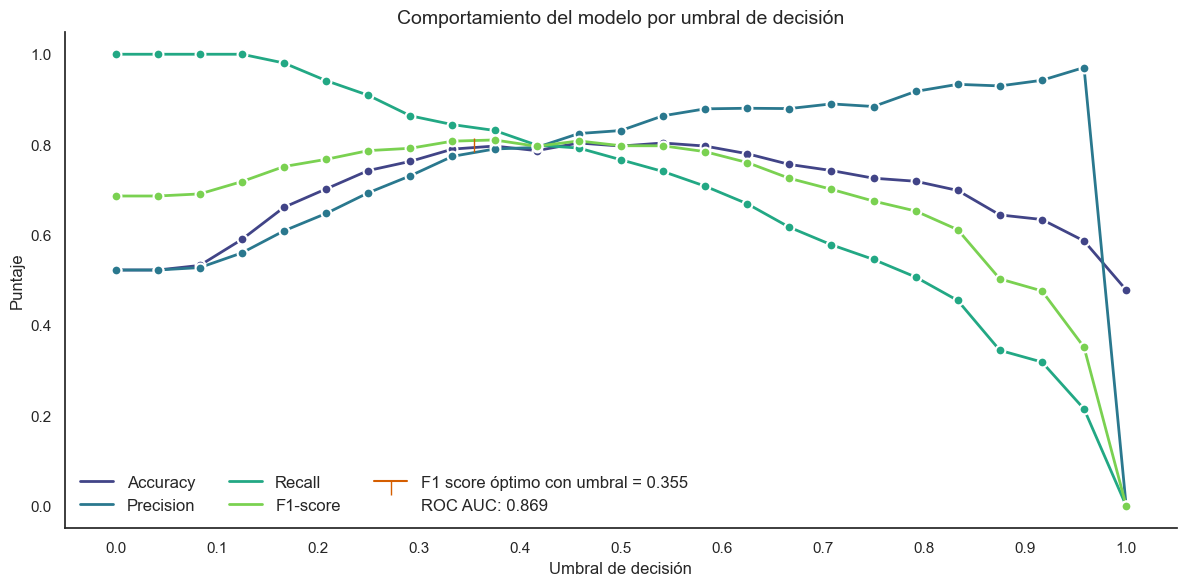

In [80]:
# Analizamos el umbral de decisión
lg_best_threshold, lg_metrics = afn.viz_threshold_behavior(lg_model, X_test, y_test, num_thresholds=25)
probs_lg = y_pred_lg[:, 1]
y_pred_proba_lg = (probs_lg >= lg_best_threshold)
lg_metrics['model'] = 'LGB Machine'

In [81]:
print(classification_report(y_test, y_pred_proba_lg))

              precision    recall  f1-score   support

         0.0       0.82      0.75      0.78       141
         1.0       0.79      0.84      0.82       154

    accuracy                           0.80       295
   macro avg       0.80      0.80      0.80       295
weighted avg       0.80      0.80      0.80       295



El área bajo la curva es la misma que en el modelo Random Forest, y las métricas obtenidas con el umbral ajustado también son muy similares. Podemos concluir que el modelo aporta mejoras mínimas respecto a Random Foresta a cargo de su mayor complejidad y costo computacional.

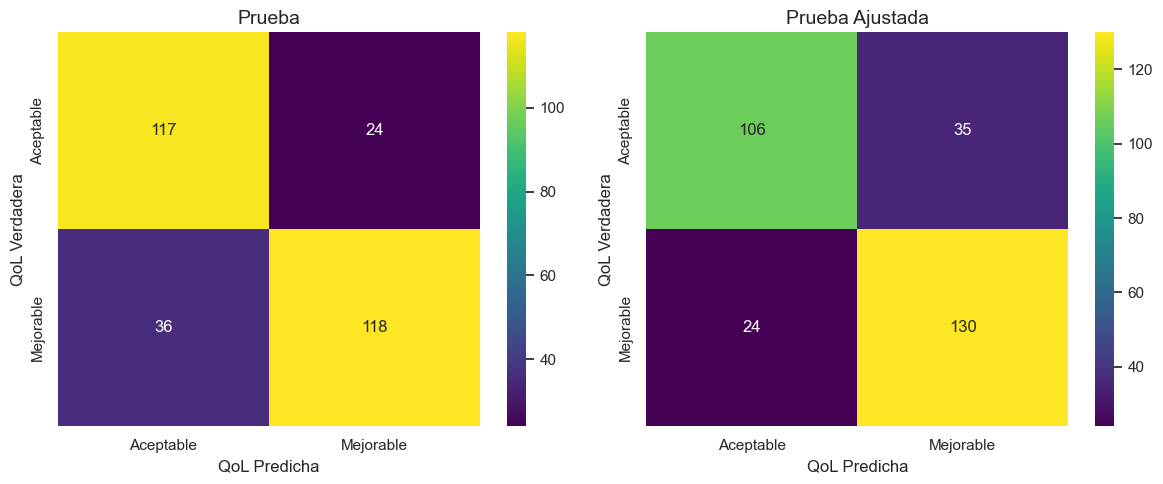

In [82]:
afn.viz_confusion_matrix_thres(labels, y_test, y_pred_val_lg, y_pred_proba_lg)

La matriz de confusión confirma nuevamnete que el modelo es capaz de realizar una clasificación muy cercana a su mejor capacidad con el umbral ajustado. Como era de esperar los resultados son muy similares al modelo de ensamble, aunque con una mejora apenas perceptible en los falsos negativos.

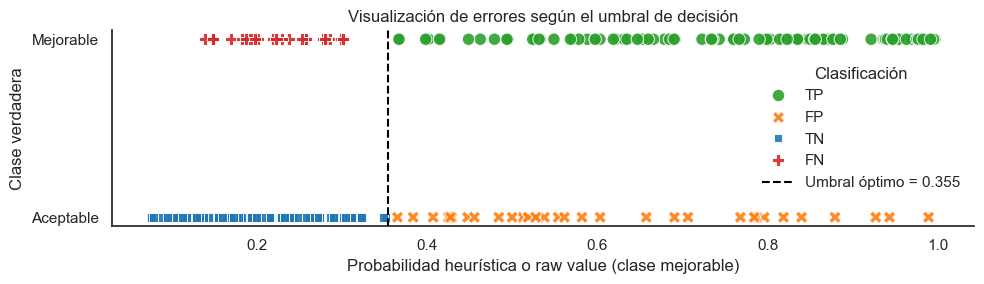

In [83]:
afn.viz_threshold_optimization(probs_lg, y_test, y_pred_proba_lg, lg_best_threshold)

El umbral de decisión se ve claramente limitado por los verdaderos negativos.

In [84]:
# Reestablecemos los nombres de las variables
X_train.columns = X_train.columns.str.replace('_', ' ')
X_test.columns = X_test.columns.str.replace('_', ' ')
X_test.columns = X_test.columns.str.replace('_', ' ')

### Comparación de los modelos

Todos los modelos han arrojado resultados muy similares, sin diferencias significativas a la hora de clasificar ambas clases. A continuación estudiaremos los resultados comparativamente para análizar más en profundidad estas pequeñas diferencias. Para ello, vamos a graficar las métricas obtenidas para cada uno de los modelos.

[codecarbon INFO @ 16:45:48] Energy consumed for RAM : 0.000100 kWh. RAM Power : 6.0 W
[codecarbon INFO @ 16:45:48] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 16:45:48] Energy consumed for All CPU : 0.000709 kWh
[codecarbon INFO @ 16:45:48] 0.000809 kWh of electricity used since the beginning.


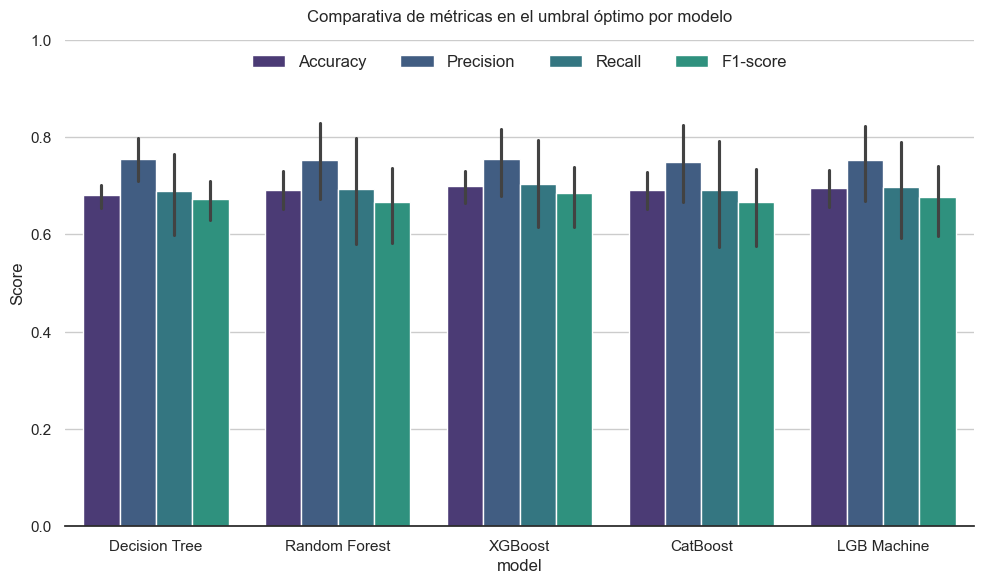

In [85]:
# Generamos un df con todas las métricas que hemos ido recolectando durtante el entrenamiento de cada modelo
all_metrics = pd.concat([dt_metrics, rf_metrics, xg_metrics, cb_metrics, lg_metrics], ignore_index=True)
melted = all_metrics.melt(id_vars='model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score'], var_name='Metric', value_name='Score')
# Graficamos los resultados 
plt.figure(figsize=(10, 6))
sns.barplot(data=melted, x='model', y='Score', hue='Metric')
plt.title('Comparativa de métricas en el umbral óptimo por modelo', y=1.02)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1), ncol=4, fontsize=12)
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
sns.despine(left=True)
plt.show()

Como era de esperar, encontramos una paridad muy alta en todos los modelos con una muy leve ventaja en Random Forest y XGBoost. Vamos a visualizar nuevamente ambas matrices de confusión para comparar los resultados.

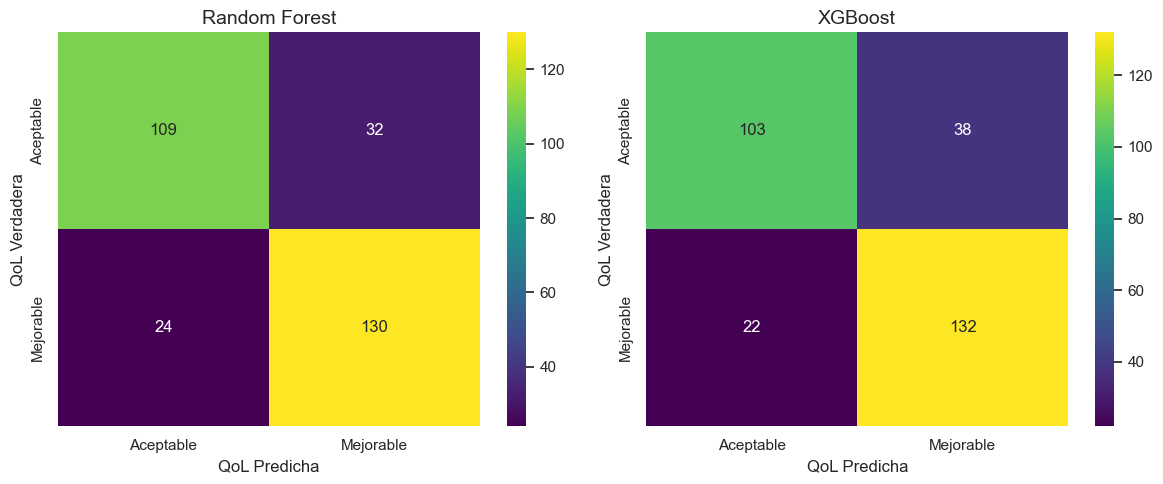

In [86]:
afn.viz_confusion_matrix_thres(labels, y_test, y_pred_proba_rf, y_pred_proba_xg, ['Random Forest', 'XGBoost'])

La matrices ajustadas muestran claramente la paridad entre ambos modelos. Si bien XGBoost consigue identificar 2 observaciones mejorables más que Random Forest, este último limita mucho más los falsos positivos. Por un lado, se evita la sobrecarga del sistema y, por otro, el costo computacional es considerablemente inferior. Por estos dos motivos seleccionamos Random Forest para continuar con el trabajo.

## 3. Conclusiones

Se han entrenado y evaluado cinco modelos: Decision Tree, Random Forest, XGBoost, CatBoost y LightGBM, utilizando validación cruzada estratificada y optimización de hiperparámetros mediante GridSearchCV. Además, se ha aplicado un ajuste fino del umbral de decisión con el objetivo de maximizar la métrica f1-score, buscando un equilibrio entre sensibilidad y precisión. Este enfoque ha demostrado ser especialmente útil para controlar los errores tipo II (falsos negativos), priorizando la detección de pacientes con QoL mejorable.

Los modelos evaluados han mostrado un rendimiento muy similar entre sí, con f1-score promedio en el conjunto de prueba en torno al 0.80. XGBoost y Random Forest han ofrecido el mejor equilibrio entre rendimiento y estabilidad, con valores altos de AUC-ROC, simetría entre clases y mínima pérdida entre entrenamiento y test.

La visualización de errores por puntuación cruda y las matrices de confusión ajustadas han aportado información valiosa para interpretar el comportamiento limítrofe de los modelos. Se ha evidenciado que el ajuste del umbral de decisión mejora la clasificación de la clase mejorable reforzando  la utilidad del ajuste manual y visual para cada clasificador.

En conjunto, se concluye que la clasificación binaria desarrollada presenta un rendimiento sólido, aunque no se puede considerar óptima en cuanto la cantidad de errores que definitivamente presentan todos los modelos. Es probable que la complejidad del conjunto de datos no permita superar el límite de clasificación alcanzado —muy similar en todos los modelos— y sea necesario enriquecer el conjunto con nuevas observaciones para estudiar posibles mejoras en el tratamiento. 

En cuanto al modelo óptimo a seleccionar, el algoritmo Random Forest ha demostrado una buena capacidad para clasificar correctamente la clase mejorable, alineándose con los objetivos del presente trabajo. Además, su simplicidad y bajo coste computacional lo posicionan como una opción preferente frente a modelos más complejos, como los algoritmos de *Boosting*, que no han aportado mejoras significativas.

## 4. Exportación del modelo seleccionado y los datos


In [87]:
bundle = {
    'model': rf_model,
    'threshold': rf_best_threshold
}
joblib.dump(bundle, './models/best_bundle.pkl')

['./models/best_bundle.pkl']

In [88]:
X_cal.to_csv('./data/QLQ_C30_C23_X_cal.csv', index=False)
y_cal.to_csv('./data/QLQ_C30_C23_y_cal.csv', index=False)
X_train.to_csv('./data/QLQ_C30_C23_X_train.csv', index=False)
X_test.to_csv('./data/QLQ_C30_C23_X_test.csv', index=False)
y_train.to_csv('./data/QLQ_C30_C23_y_train.csv', index=False)
y_test.to_csv('./data/QLQ_C30_C23_y_test.csv', index=False)

In [89]:
emissions: float = tracker.stop()  # devuelve kg CO₂e
print(f"💡 Emisiones estimadas: {emissions:.3f} kg CO₂e")

[codecarbon INFO @ 16:45:49] Energy consumed for RAM : 0.000101 kWh. RAM Power : 6.0 W
[codecarbon INFO @ 16:45:49] Delta energy consumed for CPU with constant : 0.000009 kWh, power : 42.5 W
[codecarbon INFO @ 16:45:49] Energy consumed for All CPU : 0.000718 kWh
[codecarbon INFO @ 16:45:49] 0.000820 kWh of electricity used since the beginning.


💡 Emisiones estimadas: 0.000 kg CO₂e
